**Задание №1 - Генерация выборки по плотности**

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy import stats
import math
from scipy.stats import weibull_min, norm


# 𝑓(𝑥) = 𝐴𝑥³(𝐾 − 𝑥) 𝐼(0 ≤ 𝑥 ≤ 𝐾), где 𝐾 > 0 – заданный параметр,
# 𝐴 – нормировочная константа, 𝐼(𝑥 ∈ 𝐵) = 1, если 𝑥 ∈ 𝐵 и нуль иначе.
# 𝐴 = 20 / K⁵
# 𝑓(𝑥) = (20 / K⁵) * 𝑥³ * (𝐾 − 𝑥), if x ∈ [0, K], else 0

K = 10
sample_size = 3000

def f(x):
    if 0 <= x <= K:
        return (20 / K**5) * x**3 * (K - x)
    else:
        return 0

In [ ]:
# @title График функции плотности

def plot_distribution(x_max, y_max):
    x_values = np.linspace(0, K, 100)
    y_values = [f(x) for x in x_values]

    plt.figure(figsize=(10, 6))
    plt.plot(x_values, y_values, 'b-', linewidth=2, label='f(x)')
    plt.fill_between(x_values, y_values, alpha=0.3, color='blue')

    plt.plot(x_max, y_max, 'ro', markersize=8, label=f'Максимум: x={x_max:.3f}, f(x)={y_max:.3f}')

    plt.title(f'Функция плотности распределения f(x) при K={K}', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('f(x)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.xlim(0, K)
    plt.ylim(0, y_max * 1.1)

    plt.text(0.05, 0.95, f'f(x) = (20/{K}⁵) · x³ · ({K}-x)',
             transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

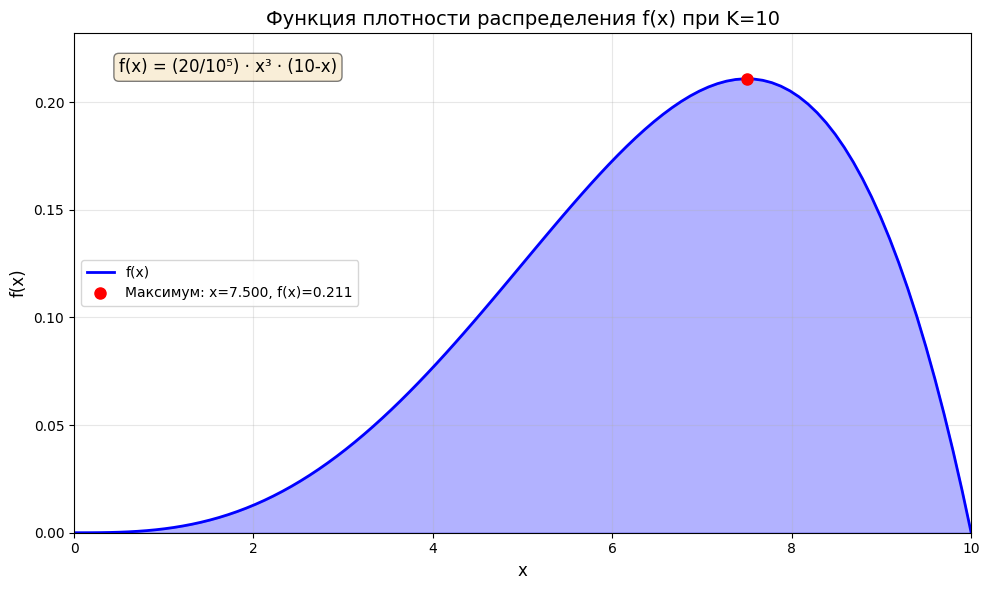

Сгенерировано 3000 значений за 6343 попыток
Эффективность метода: 47.3%


In [ ]:
result = minimize_scalar(lambda x: -f(x), bounds=(0, K), method='bounded')
x_max, y_max = result.x, f(result.x)
plot_distribution(x_max, y_max)

sample = []
attempts = 0

while len(sample) < sample_size:
    attempts += 1
    u1 = random.uniform(0, 1)
    u2 = random.uniform(0, 1)

    x = K * u1
    y = y_max * u2

    if y <= f(x):
        sample.append(x)

print(f"Сгенерировано {sample_size} значений за {attempts} попыток")
print(f"Эффективность метода: {sample_size/attempts*100:.1f}%")

In [ ]:
sample = np.array(sample)

beta_sample = K * np.random.beta(4, 2, sample_size)

def theoretical_cdf(x):
    return stats.beta.cdf(x / K, 4, 2)

D, p_value = stats.kstest(sample, theoretical_cdf)

print("\nКритерий Колмогорова–Смирнова:")
print(f"D = {D:.5f}")
print(f"p-value = {p_value:.5f}")

if p_value > 0.05:
    print("Гипотеза согласия НЕ отвергается (alpha=0.05)")
else:
    print("Гипотеза согласия отвергается (alpha=0.05)")


Критерий Колмогорова–Смирнова:
D = 0.01530
p-value = 0.47918
Гипотеза согласия НЕ отвергается (alpha=0.05)


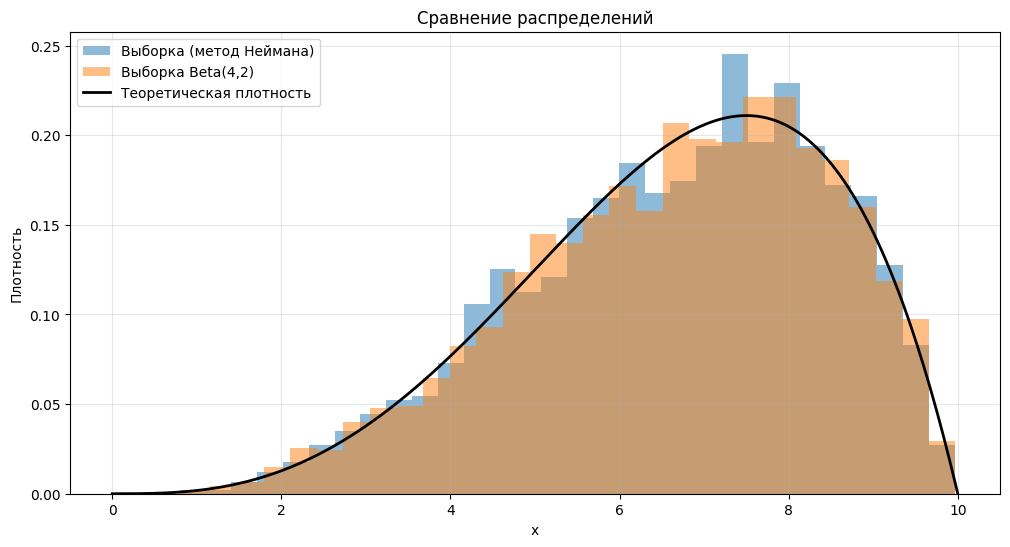

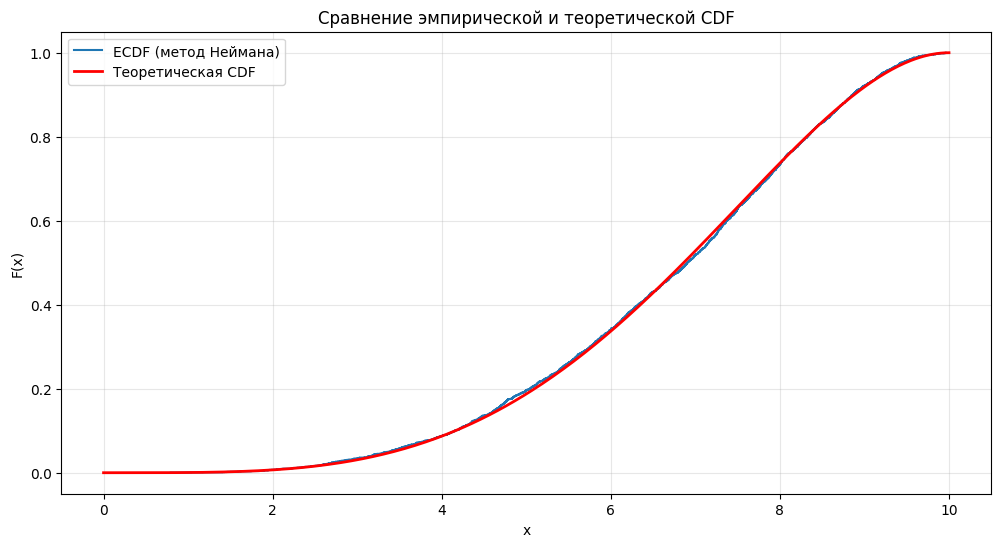

In [ ]:
x_vals = np.linspace(0, K, 400)

plt.figure(figsize=(12, 6))

plt.hist(sample, bins=30, density=True, alpha=0.5, label="Выборка (метод Неймана)")
plt.hist(beta_sample, bins=30, density=True, alpha=0.5, label="Выборка Beta(4,2)")

plt.plot(x_vals, [f(x) for x in x_vals], 'k-', linewidth=2, label="Теоретическая плотность")

plt.title("Сравнение распределений")
plt.xlabel("x")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))

x_sorted = np.sort(sample)
ecdf = np.arange(1, sample_size+1) / sample_size
plt.step(x_sorted, ecdf, where="post", label="ECDF (метод Неймана)")

plt.plot(x_vals, theoretical_cdf(x_vals), 'r-', linewidth=2, label="Теоретическая CDF")

plt.title("Сравнение эмпирической и теоретической CDF")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Задание №2 - рассчет NPV**

In [ ]:
# T - срок (в годах)
# d ∈ (0, 1) - ставка дисконтирования
# Q - единиц продукции в год. 𝑄1, ..., 𝑄t: Qi ~ U[𝑄𝑚𝑖𝑛, 𝑄𝑚𝑎𝑥] для каждый i, cov(Qi, Qj) = 0 для каждой пары (i,j);
# P - цена в у.е. за единицу товара. P1, ..., Pt: Pi ~ U[P𝑚𝑖𝑛, P𝑚𝑎𝑥] для каждый i, cov(Pi, Pj) = 0 для каждой пары (i,j);
# V - затраты на изготовление единицы продукции. V1, ..., Vt: Vi ~ U[V𝑚𝑖𝑛, V𝑚𝑎𝑥] для каждый i, cov(Vi, Vj) = 0 для каждой пары (i,j);
# Ежегодный чистый доход 𝑁𝐶𝐹𝑗 = (𝑄𝑗 × (𝑃𝑗 − 𝑉𝑗 ) − 𝐶 − 𝐴) × (1 − 𝑟), 𝑗 = 1, ..., 𝑇, где 𝑟 ∈ (0, 1) – ставка налога на прибыль; 𝐶 – постоянные расходы; 𝐴 – амортизация.
#
# На основе 𝑁 прогонов имитационной модели найти оценки математического ожидания, дисперсии и коэффициента вариации чистого приведенного дохода (NPV).


In [ ]:
N = 1000

# d = round(random.uniform(0, 1), 3)
# r = round(random.uniform(0, 1), 3)
# C = random.randint(10000, 12000)
# A = random.randint(10000, 12000)
T = 5
d = 0.1     # ставка дисконтирования
r = 0.2      # налог
C = 1000  # постоянные расходы
A = 500    # амортизация

NPV_values = []

for k in range(N):
    Q_sample = np.random.uniform(100, 200, T)
    P_sample = np.random.uniform(50, 70, T)
    V_sample = np.random.uniform(20, 30, T)

    NPV = 0
    for i in range(T):
        NCF = (Q_sample[i] * (P_sample[i] - V_sample[i]) - C - A) * (1 - r)
        NPV += NCF / (1 + d)**(i + 1)

    NPV_values.append(NPV)

NPV_values = np.array(NPV_values)

mean = np.mean(NPV_values)
variance = np.var(NPV_values)
std = np.std(NPV_values)
cv = std / mean

# E(NPV) — средняя эффективность проекта
# Var(NPV) — мера риска
# CV = σ / E(NPV) — относительный риск

# CV < 0.3 → риск умеренный
# CV > 0.5 → риск высокий

print("Мат.ожидание(NPV) =", mean)
print("Дисперсия(NPV) =", variance)
print("Коэффициент вариации", cv)


Мат.ожидание(NPV) = 11397.873590609383
Дисперсия(NPV) = 3888063.9102347433
Коэффициент вариации 0.17299870869166645


**Задание №3 - ветрогенератор**

In [ ]:
# скорость ветра 𝑉 является случайной величной с известным законом распределения - два случая:
# 1. Распределение Вейбулла с функцией распределения 𝐹𝑉(𝑣) = 1 − exp (︀−(𝑣/𝜆)^𝛽)︀, 𝑣 > 0.
# 2. усеченное до интервала 𝐼 = (𝑎, 𝑏) распределение Вейбулла с функцией распределения 𝐹𝑉 |𝑉 ∈𝐼 (𝑣) = P(𝑉 ≤ 𝑣|𝑉 ∈ 𝐼) (предполагается, что P(𝑉 ∈ 𝐼) > 0).

(np.float64(0.7015686714735553), np.float64(0.7103803912314118))


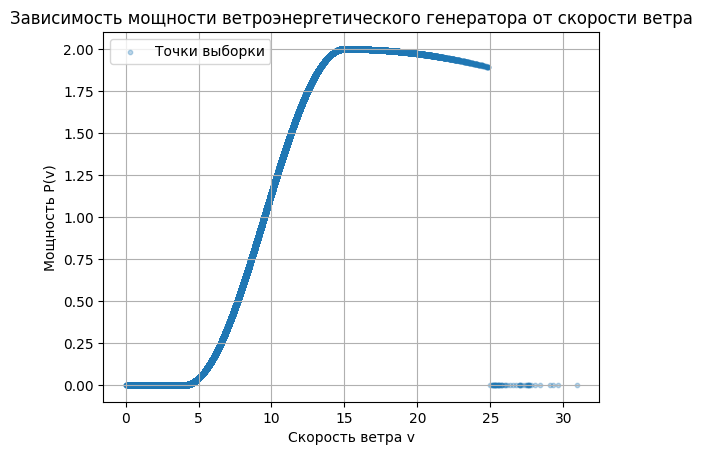

In [ ]:
# @title 3.1. Полнное распределение
def P(v):
  if v < 4:
    return 0
  if v < 15:
    return math.cos(v * math.pi / 11 + 7 * math.pi / 11) + 1
  if v < 25:
    return 7 / 4 + v / 30  - v**2 / 900
  else:
    return 0

beta = 2   # параметр формы
λ = 9.0      # параметр масштаба
n = 100000

rng = np.random.default_rng()
sample = λ * rng.weibull(beta, n)

P_for_sample = list(map(P, sample))

z = norm.ppf(0.975) # Для 95% ДИ квантиль 0.975
interval = (
    np.mean(P_for_sample) - z * (np.std(P_for_sample, ddof=1) / math.sqrt(n)),
    np.mean(P_for_sample) + z * (np.std(P_for_sample, ddof=1) / math.sqrt(n))
)
print(interval)

plt.scatter(sample, P_for_sample, alpha=0.3, s=10, label="Точки выборки")
plt.xlabel("Скорость ветра v")
plt.ylabel("Мощность P(v)")
plt.title("Зависимость мощности ветроэнергетического генератора от скорости ветра")
plt.grid(True)
plt.legend()
plt.show()


(np.float64(0.9459347056847739), np.float64(0.9541635210255947))


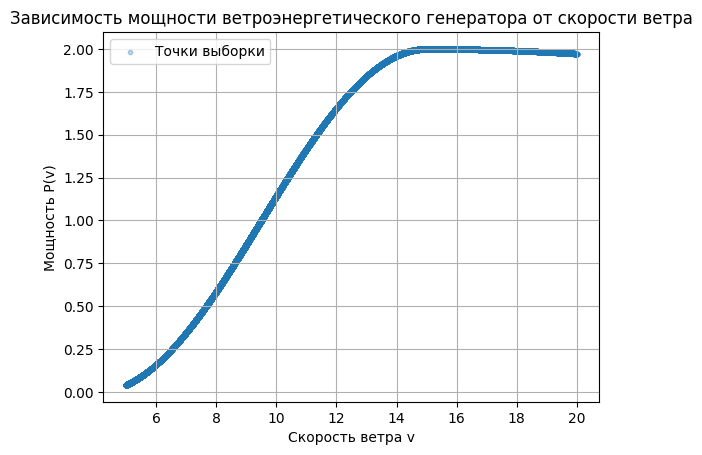

In [ ]:
# @title 3.2. Усеченное до (a,b) распределение

a = 5
b = 20

def F(v):
    return 1 - np.exp(-(v/λ)**beta)

Fa = F(a)
Fb = F(b)

u = rng.uniform(0, 1, n)
u_scaled = Fa + u * (Fb - Fa)

sample = λ * (-np.log(1 - u_scaled))**(1/beta) # F−1(u)=λ(−ln(1−u))1/β
P_for_sample = np.array(list(map(P, sample)))

mean = np.mean(P_for_sample)
std = np.std(P_for_sample, ddof=1)

z = norm.ppf(0.975)
interval = (
    mean - z * std / math.sqrt(n),
    mean + z * std / math.sqrt(n)
)

print(interval)

plt.scatter(sample, P_for_sample, alpha=0.3, s=10, label="Точки выборки")
plt.xlabel("Скорость ветра v")
plt.ylabel("Мощность P(v)")
plt.title("Зависимость мощности ветроэнергетического генератора от скорости ветра")
plt.grid(True)
plt.legend()
plt.show()

**Задание №4 - Популяция**

In [ ]:
# A(𝑡) = 𝑚 𝑡 + 𝑋(𝑡), где 𝑚 > 0 – средняя скорость роста, 𝑋 – центрированный гауссовский процесс с ковариационной функцией
# 𝛾(𝑡, 𝑠) = 1/2 * (𝑡2𝐻 + 𝑠2𝐻 − |𝑡 − 𝑠|2𝐻), где 𝐻 ∈ (0, 1) – заданный параметр.
# Ищем: T𝐷 = min(𝑡 : 𝐴(𝑡) ≥ 𝐷), где 𝐷 – некоторое заданное пороговое значение популяции.
# Оценить математическое ожидание E[𝑇𝐷], а также условное математическое ожидание E[𝑇𝐷 | 𝑇𝐷 ≥ 𝑉 ], 𝑉 – заданное значение.

In [ ]:
H = 0.75           # параметр Херста
T_max = 50.0       # максимальное время моделирования
N = 1000           # число точек сетки времени
m = 0.7             # средняя скорость роста
D = 5             # пороговое значение
M = 10000          # число реализаций
V = 5           # условное значение для E[T_D | T_D >= V]
eps = 1e-10       # маленький шум для численной устойчивости


t = np.linspace(0, T_max, N)

Sigma = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        Sigma[i, j] = 0.5 * (t[i]**(2*H) + t[j]**(2*H) - abs(t[i] - t[j])**(2*H))

noise = eps * np.eye(N)
L = np.linalg.cholesky(Sigma + noise) #  Σ = L*L^T  типо транспонированная

# print(L)  # видно что она нижнетреугольная

def simulate_population():
    Z = np.random.randn(N)      # независимые Z ∼ N(0,I)
    X = L @ Z                   # коррелированный гауссовский процесс X ∼ N(0,Σ)
    A = m * t + X
    return A

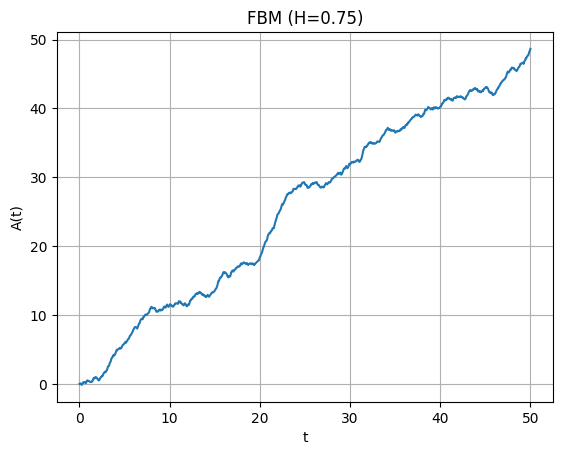

In [ ]:
trajectory = simulate_population()
plt.plot(t, trajectory)
plt.title(f"FBM (H={H})")
plt.xlabel("t")
plt.ylabel("A(t)")
plt.grid()
plt.show()

In [ ]:
T_D_samples = []

for _ in range(M):
    trajectory = simulate_population()
    for i in range(N):
        if trajectory[i] >= D:
            T_D_samples.append(t[i])
            break

T_D_conditional = [t_val for t_val in T_D_samples if t_val >= V]

E_T_D = np.mean(T_D_samples)
E_T_D_given_V = np.mean(T_D_conditional)

print(f"E[T_D] = {E_T_D:.4f}")
print(f"E[T_D | T_D >= {V}] = {E_T_D_given_V:.4f}")

E[T_D] = 9.4789
E[T_D | T_D >= 5] = 12.6384


**Задание №5 - Протоны**

In [ ]:
E0 = 1.0
l = 1.5
d = 10.0
N = 100000

def random_isotropic_direction():
    # (dx² + dy² + dz² = 1)
    phi = random.uniform(0, 2 * math.pi)  # Азимутальный угол φ
    cos_theta = random.uniform(-1, 1)     # Полярный угол θ
    sin_theta = math.sqrt(1 - cos_theta**2)

    dx = sin_theta * math.cos(phi)   # Слайд 38!
    dy = sin_theta * math.sin(phi)
    dz = cos_theta
    return dx, dy, dz

def simulate_proton(E0, l, d):
    x, y, z = 0.0, 0.0, 0.0
    dx, dy, dz = 0.0, 0.0, 1.0  # начальное направление внутрь стены
    energy = E0
    collisions = 0

    while True:
        free_path = random.expovariate(1/l)

        new_z = z + dz * free_path

        if new_z > d:
            return "passed", energy, collisions
        if new_z < 0:
            return "backscattered", energy, collisions

        x += dx * free_path
        y += dy * free_path
        z = new_z

        energy_loss = random.uniform(0, E0)
        energy -= energy_loss
        collisions += 1

        if energy <= 0:
            return "stopped", 0, collisions

        dx, dy, dz = random_isotropic_direction()

    # return "stopped", energy, collisions

In [ ]:
passed_count = 0
total_energy_loss_passed = 0.0

for _ in range(N):
    status, final_energy, _ = simulate_proton(E0, l, d)

    if status == "passed":
        passed_count += 1
        total_energy_loss_passed += (E0 - final_energy)

if passed_count > 0:
    avg_loss = total_energy_loss_passed / passed_count
else:
    avg_loss = 0

print(f"Всего протонов: {N}")
print(f"Прошло стену: {passed_count}")
print(f"Доля прошедших: {passed_count / N:.4f}")
print(f"Средняя потеря энергии (среди прошедших): {avg_loss:.4f}")

Всего протонов: 100000
Прошло стену: 365
Доля прошедших: 0.0037
Средняя потеря энергии (среди прошедших): 0.4107
